# The Cycle Hunt — a quantitative teardown \U0001F52C
### Fisher's exact g test · AR(1) nulls · a natural-gas positive control · phase agreement

![Signal: Busted](https://img.shields.io/badge/Signal-Busted-c0392b?style=flat-square)
![Tradability: Partial](https://img.shields.io/badge/Tradability-Partial-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Two corrections
do all the work: the multiple-comparison problem across frequency bins (Fisher solved it in
1929), and the fact that the right null is not white noise but an autocorrelated one.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date in
> [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from cyclehunt import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
assets = {tk: rets[tk].dropna() for tk in data.TICKERS
          if tk != data.CASH and rets[tk].notna().sum() > 1000}
lead = assets[data.EQUITY]
pg = st.periodogram(lead)
print(f"as-of {data.AS_OF} | {data.EQUITY}: {len(lead):,} sessions -> "
      f"{len(pg):,} frequency bins")

as-of 2026-06-30 | SPY: 7,764 sessions -> 3,882 frequency bins


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Busted | Across 7 assets the strongest spectral peak averaged **8.0× the average power**, which sounds like a finding until you compute what noise gives. With 3,882 frequency bins the periodogram ordinates are independent exponentials, so their maximum is expected at **8.8×** the mean — and simulating random walks of the same length put the 95th percentile at **10.3×**. Fisher's *g* test, which has had the correct answer since 1929, rejected the null for **0 of 7** assets against white noise and **1** against an AR(1) null — and the AR(1) column is the honest one, because returns are autocorrelated and a flat null tilts every test toward finding long cycles. The positive control worked: UNG, which has a genuine annual demand cycle, showed a peak at **246 sessions** (0.98 years), so the machinery detects cycles when they exist. On SPY the best period found in the first half of the sample was 14 sessions and in the second half 8, and the phase coherence was **0.49** against the 0.70 needed to call a cycle coherent — which is what no cycle looks like. |
| **Tradability** | Partial | Trading the best detected period out of sample — fitting the sinusoid on a rolling 1000-session window and taking the next step's sign — returned +2.47%/yr at a Sharpe of **0.22**, with a 52.2% hit rate against the 50% a coin gives, and 108 position changes a year to pay for. Buy-and-hold over the same window returned +9.65%. That is the expected outcome for a peak that is a peak because some bin has to be the largest. |

> \U0001F4A1 **In plain words.** The peaks are real numbers. What they are not is evidence,
> until compared against what noise of the same length produces.

## 1 · Hypotheses

- **H₁ (the null benchmark).** The largest ordinate of a white-noise periodogram over *m* bins
  is distributed with mean ≈ `log(m) + 0.577` times the spectrum.
- **H₂ (Fisher).** The exact test rejects at the nominal rate on white noise and detects a
  planted sinusoid.
- **H₃ (the right null).** Testing against an AR(1) rather than white noise materially changes
  which peaks survive, because returns are autocorrelated.
- **H₄ (positive control).** The method detects a genuine annual cycle where one exists.
- **H₅ (persistence).** A real cycle keeps its period *and phase* across sample halves; a
  spurious one keeps neither.
- **H₆ (power).** State the smallest amplitude the method could have detected, so that "found
  nothing" is a bounded claim.

## 2 · The periodogram, and the choices inside it

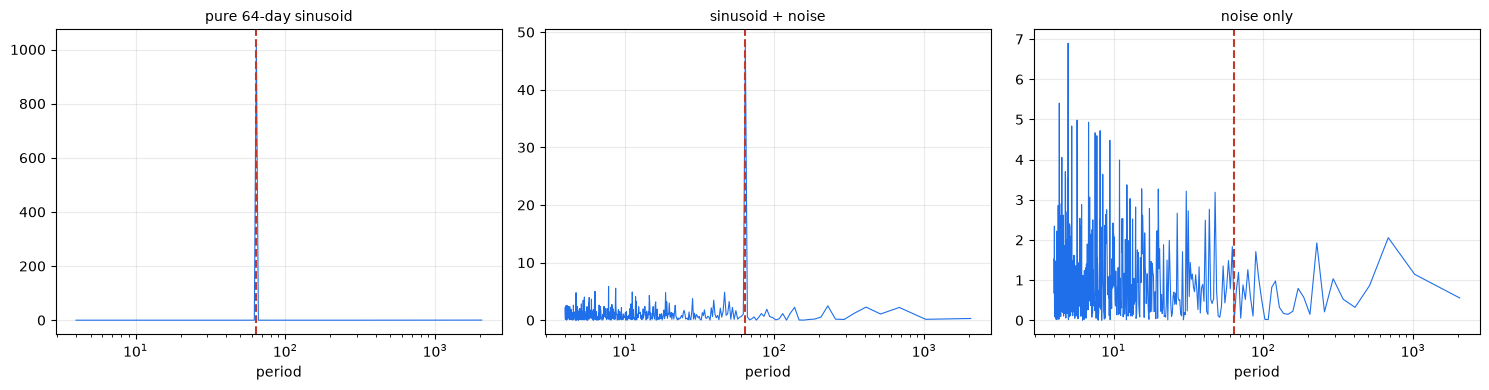

In [3]:
n = 2048
t = np.arange(n)
clean = pd.Series(np.sin(2 * np.pi * t / 64), index=pd.bdate_range("1993-02-01", periods=n))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, series) in zip(axes, [
        ("pure 64-day sinusoid", clean),
        ("sinusoid + noise", clean + pd.Series(np.random.default_rng(1).normal(0, 3, n),
                                               index=clean.index)),
        ("noise only", pd.Series(np.random.default_rng(2).normal(0, 3, n),
                                 index=clean.index))]):
    p = st.periodogram(series)
    d = p[p["period"] >= 4]
    ax.semilogx(d["period"], d["power"] / p["power"].mean(), lw=0.8, color="#1f6feb")
    ax.axvline(64, color="#c0392b", ls="--", lw=1.5)
    ax.set_title(name, fontsize=10); ax.set_xlabel("period")
plt.tight_layout(); plt.show()

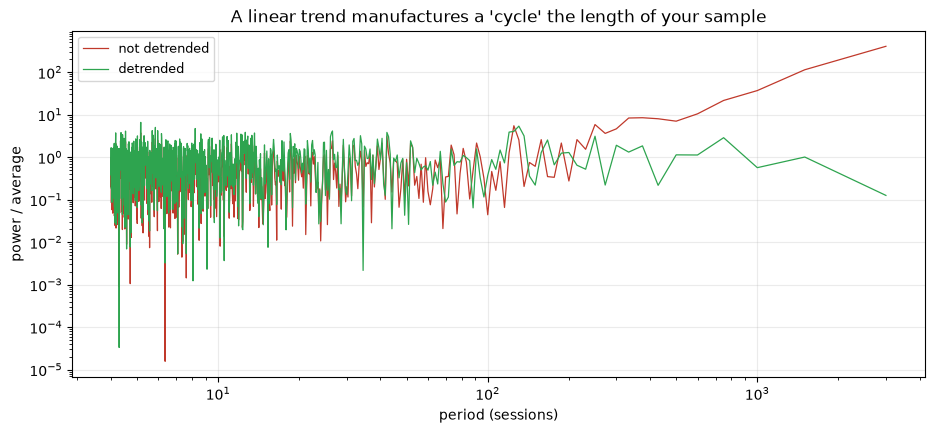

In [4]:
# detrending: the artefact that makes fake long cycles
rng = np.random.default_rng(1000)
n = 3000
trended = pd.Series(0.001 * np.arange(n) + rng.normal(0, 1, n),
                    index=pd.bdate_range("1993-02-01", periods=n))
fig, ax = plt.subplots(figsize=(11, 4.5))
for detrend, colour, label in ((False, "#c0392b", "not detrended"),
                               (True, "#2ea44f", "detrended")):
    p = st.periodogram(trended, detrend=detrend)
    d = p[p["period"] >= 4]
    ax.loglog(d["period"], d["power"] / p["power"].mean(), lw=0.9, color=colour,
              label=label)
ax.set_xlabel("period (sessions)"); ax.set_ylabel("power / average"); ax.legend(fontsize=9)
ax.set_title("A linear trend manufactures a 'cycle' the length of your sample")
plt.show()

> \U0001F4A1 **In plain words.** The red line's giant low-frequency peak is not a cycle. It is a
> straight line. Nelson & Kang (1981) is the paper; the artefact is still everywhere.

## 3 · The teardown

### 3.1 The noise benchmark, three ways

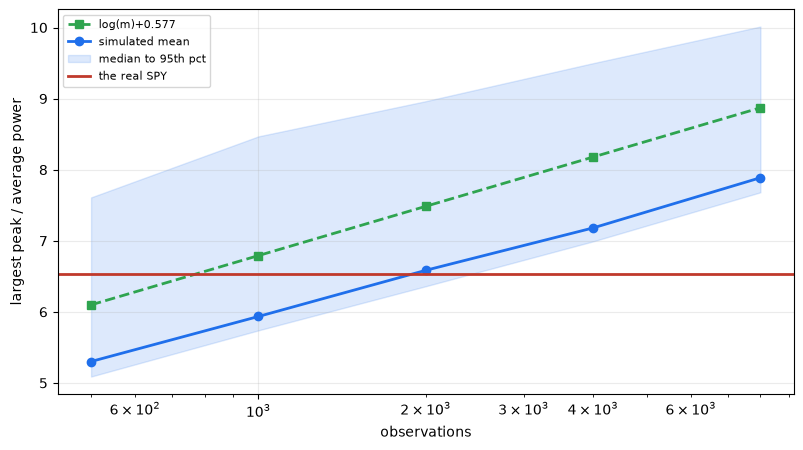

,bins,theory,sim mean,sim median,sim p95
n,,,,,
500,250,6.1000,5.3000,5.0900,7.6100
1000,500,6.7900,5.9400,5.7400,8.4700
2000,1000,7.4800,6.5800,6.3600,8.9600
4000,2000,8.1800,7.1800,6.9900,9.5000
8000,4000,8.8700,7.8900,7.6800,10.0100


In [5]:
rows = []
for n_obs in (500, 1000, 2000, 4000, 8000):
    sim = st.spurious_peak_distribution(n_obs, n_sims=200, min_period=5.0)
    rows.append({"n": n_obs, "bins": n_obs // 2, "theory": sim["theoretical"],
                 "sim mean": sim["mean_max"], "sim median": sim["median_max"],
                 "sim p95": sim["p95_max"]})
d = pd.DataFrame(rows).set_index("n")
fig, ax = plt.subplots(figsize=(9.5, 5))
ax.semilogx(d.index, d["theory"], "s--", lw=2, color="#2ea44f", label="log(m)+0.577")
ax.semilogx(d.index, d["sim mean"], "o-", lw=2, color="#1f6feb", label="simulated mean")
ax.fill_between(d.index, d["sim median"], d["sim p95"], alpha=0.15, color="#1f6feb",
                label="median to 95th pct")
ax.axhline(pg[pg["period"] >= 5]["power"].max() / pg["power"].mean(), color="#c0392b",
           lw=2, label=f"the real {data.EQUITY}")
ax.set_xlabel("observations"); ax.set_ylabel("largest peak / average power")
ax.legend(fontsize=8)
plt.show()
d.round(2)

### 3.2 Fisher's test: size and power

size on white noise: rejects in 6/60 = 10.0% (nominal 5%)


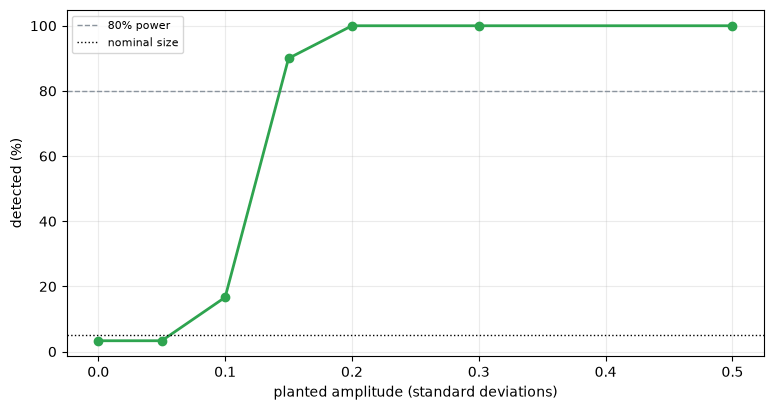

,detection rate
amplitude (sd),
0.0000,0.0330
0.0500,0.0330
0.1000,0.1670
0.1500,0.9000
0.2000,1.0000
0.3000,1.0000
0.5000,1.0000


In [6]:
rejects = 0
n_runs = 60
for k in range(n_runs):
    x = st.synthetic_series(n=2000, seed=1000 + k)
    rejects += bool(st.fisher_g_test(st.periodogram(x)).get("significant_5pct"))
print(f"size on white noise: rejects in {rejects}/{n_runs} = {rejects / n_runs:.1%} "
      f"(nominal 5%)")
rows = []
for amp in (0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5):
    hits = 0
    for k in range(30):
        x = st.synthetic_series(n=4000, period=126.0, amplitude=amp, seed=1000 + k)
        hits += bool(st.fisher_g_test(st.periodogram(x)).get("significant_5pct"))
    rows.append({"amplitude (sd)": amp, "detection rate": hits / 30})
d = pd.DataFrame(rows).set_index("amplitude (sd)")
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(d.index, d["detection rate"] * 100, "o-", lw=2, color="#2ea44f")
ax.axhline(80, ls="--", color="#8b949e", lw=1, label="80% power")
ax.axhline(5, ls=":", color="k", lw=1, label="nominal size")
ax.set_xlabel("planted amplitude (standard deviations)")
ax.set_ylabel("detected (%)"); ax.legend(fontsize=8)
plt.show()
d.round(3)

### 3.3 The AR(1) null, which is the right one

            phi   tilt  peak (white)  power (white)  peak (AR1)  power (AR1)  same peak
asset                                                                                  
SPY     -0.0710 0.8680        4.0820         9.5870      4.0820       9.7270       True
QQQ     -0.0490 0.9060        2.7090         8.9690      2.7090       8.4120       True
IWM     -0.0660 0.8760        2.7480         8.0310      3.0590       7.4770      False
TLT     -0.0240 0.9540        2.1860         7.1040      2.1860       6.7890       True
GLD     -0.0280 0.9460       19.5470         6.5730     19.5470       6.9300       True
BTC-USD -0.0230 0.9550        2.4190         6.6890  1,434.6670       6.7950      False
UNG     -0.0660 0.8760        2.1460         8.8500      2.1460       7.7790       True


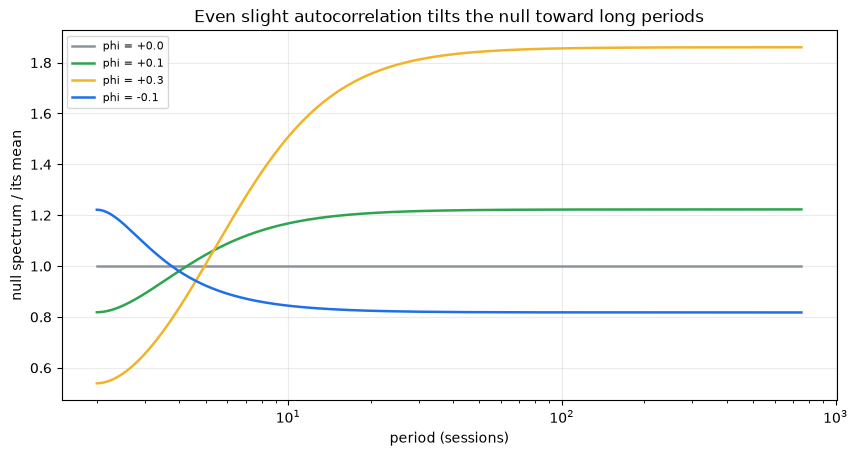

In [7]:
rows = []
for tk, s in assets.items():
    p = st.periodogram(s)
    a1 = st.ar1_null(s)
    pa = st.peak_against_ar1(p, a1["phi"])
    rows.append({"asset": tk, "phi": a1["phi"], "tilt": a1["spectrum_tilt"],
                 "peak (white)": pa["peak_period_white"],
                 "power (white)": pa["relative_power_white"],
                 "peak (AR1)": pa["peak_period_ar1"],
                 "power (AR1)": pa["relative_power_ar1"],
                 "same peak": pa["same_peak"]})
d = pd.DataFrame(rows).set_index("asset")
print(d.round(3).to_string())
f = np.linspace(1 / 750, 0.5, 400)
fig, ax = plt.subplots(figsize=(10, 4.8))
for phi, colour in ((0.0, "#8b949e"), (0.1, "#2ea44f"), (0.3, "#f0b429"),
                    (-0.1, "#1f6feb")):
    sd = st.ar1_spectral_density(f, phi)
    ax.semilogx(1 / f, sd / sd.mean(), lw=1.8, color=colour, label=f"phi = {phi:+.1f}")
ax.set_xlabel("period (sessions)"); ax.set_ylabel("null spectrum / its mean")
ax.legend(fontsize=8)
ax.set_title("Even slight autocorrelation tilts the null toward long periods")
plt.show()

> \U0001F4A1 **In plain words.** A flat null says every period is equally likely a priori. An
> AR(1) null says long periods should already have more power. Testing a long-period peak
> against a flat null is grading it against the wrong baseline, and it is the reason "we found a
> multi-year cycle" is the most common false positive in this literature.

### 3.4 The positive control

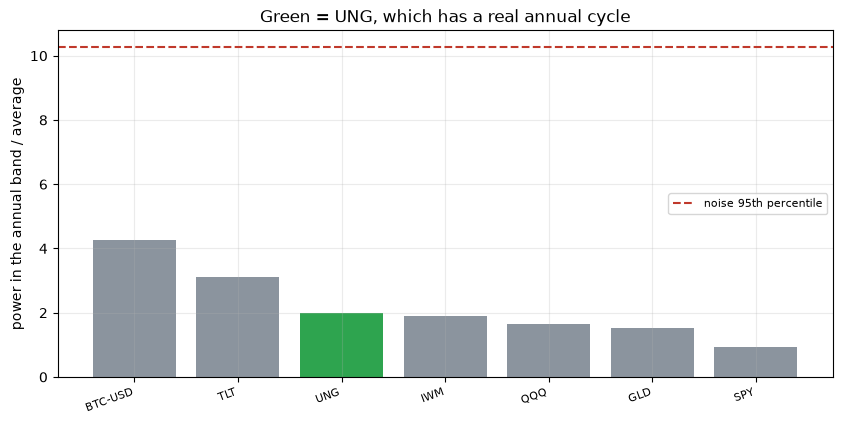

,best annual-band period,power
asset,,
BTC-USD,286.9300,4.2600
TLT,223.7900,3.1100
UNG,246.1200,1.9900
IWM,227.4600,1.9000
QQQ,230.4400,1.6300
GLD,281.7100,1.5300
SPY,228.3500,0.9200


In [8]:
ctrl = data.SEASONAL
rows = []
for tk, s in assets.items():
    p = st.periodogram(s)
    ann = st.top_peaks(p, 1, min_period=200.0, max_period=320.0)
    if ann.empty:
        continue
    rows.append({"asset": tk, "best annual-band period": ann.iloc[0]["period"],
                 "power": ann.iloc[0]["relative_power"]})
d = pd.DataFrame(rows).set_index("asset").sort_values("power", ascending=False)
fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ["#2ea44f" if i == ctrl else "#8b949e" for i in d.index]
ax.bar(range(len(d)), d["power"], color=colors)
sim = st.spurious_peak_distribution(len(lead), n_sims=200, min_period=5.0)
ax.axhline(sim["p95_max"], ls="--", color="#c0392b", lw=1.5, label="noise 95th percentile")
ax.set_xticks(range(len(d))); ax.set_xticklabels(d.index, rotation=20, ha="right",
                                                 fontsize=8)
ax.set_ylabel("power in the annual band / average"); ax.legend(fontsize=8)
ax.set_title(f"Green = {ctrl}, which has a real annual cycle")
plt.show()
d.round(2)

### 3.5 Period and phase across sample halves

               period_first  period_second  period_ratio  amplitude_decay  phase_error_fraction
asset                                                                                          
SPY                 13.5730         7.7640        0.5720           0.4680                0.4050
QQQ                  5.6460         8.1230        1.4390           0.2260                0.6090
IWM                  9.7590         9.5390        0.9770           0.4460                0.7800
TLT                  6.1580        15.8930        2.5810           0.4650                0.0630
GLD                  8.5200        18.2820        2.1460           0.2490                0.9700
BTC-USD              8.3410        11.3260        1.3580           0.2000                0.0460
UNG                  6.3780         8.3350        1.3070           0.2920                0.5930
planted cycle      121.3120       121.3120        1.0000           0.9220                0.7270
planted noise        5.6920         9.97

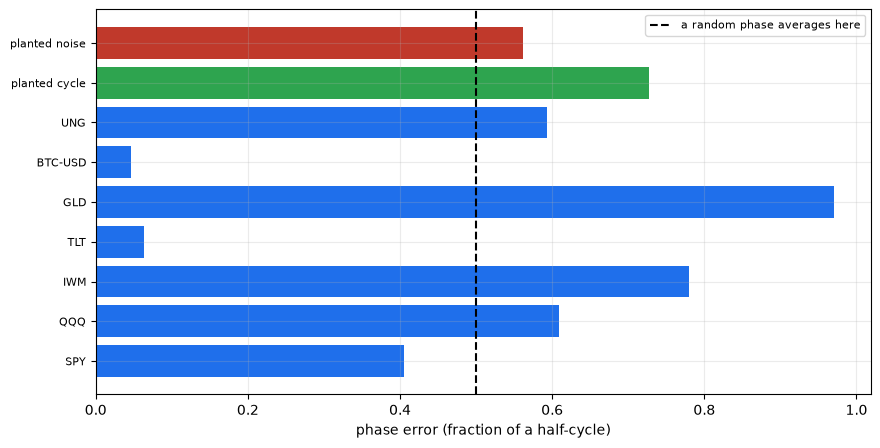

In [9]:
rows = []
for tk, s in assets.items():
    o = st.split_sample_peak(s, 5.0, 750.0)
    if "period_ratio" in o:
        rows.append({"asset": tk, **{k: o[k] for k in
                     ("period_first", "period_second", "period_ratio",
                      "amplitude_decay", "phase_error_fraction")}})
for amp, tag in ((0.5, "planted cycle"), (0.0, "planted noise")):
    x = st.synthetic_series(n=len(lead), period=120.0, amplitude=amp)
    o = st.split_sample_peak(x, 5.0, 750.0)
    rows.append({"asset": tag, **{k: o[k] for k in
                 ("period_first", "period_second", "period_ratio",
                  "amplitude_decay", "phase_error_fraction")}})
d = pd.DataFrame(rows).set_index("asset")
print(d.round(3).to_string())
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2ea44f" if i == "planted cycle" else
          ("#c0392b" if i == "planted noise" else "#1f6feb") for i in d.index]
ax.barh(range(len(d)), d["phase_error_fraction"], color=colors)
ax.axvline(0.5, ls="--", color="k", lw=1.5, label="a random phase averages here")
ax.set_yticks(range(len(d))); ax.set_yticklabels(d.index, fontsize=8)
ax.set_xlabel("phase error (fraction of a half-cycle)"); ax.legend(fontsize=8)
plt.show()

### 3.6 Trading the peak, out of sample

                       cagr  sharpe  hit rate  switches/yr
period                                                    
10.0000             -0.0113  0.0404    0.5281      46.5328
21.0000             -0.0062  0.0664    0.5179      24.4772
42.0000             -0.0021  0.0872    0.5176      17.4731
63.0000              0.0436  0.3165    0.5200      13.3749
126.0000             0.0335  0.2669    0.5241       7.7865
252.0000             0.0070  0.1338    0.5197       8.9787
5.6424               0.0247  0.2225    0.5225     107.7818
 63 (planted, real)  3.7967  9.5549    0.7246      16.0574


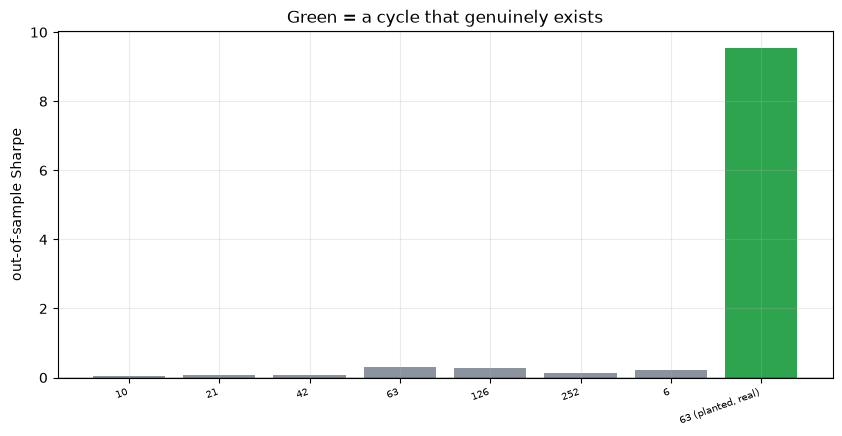

In [10]:
best = st.top_peaks(pg, 1, 5.0, 750.0).iloc[0]["period"]
rows = []
for per in (10.0, 21.0, 42.0, 63.0, 126.0, 252.0, float(best)):
    t2 = st.cycle_trade(lead, per, fit_window=1000, cost_bps=5.0)
    if "sharpe" not in t2:
        continue
    rows.append({"period": per, "cagr": t2["cagr"], "sharpe": t2["sharpe"],
                 "hit rate": t2["hit_rate"], "switches/yr": t2["switches_per_year"]})
# and the same on a series with a genuine cycle
real = st.synthetic_series(n=len(lead), period=63.0, amplitude=1.0)
tr = st.cycle_trade(real, 63.0, fit_window=1000, cost_bps=5.0)
rows.append({"period": "63 (planted, real)", "cagr": tr["cagr"], "sharpe": tr["sharpe"],
             "hit rate": tr["hit_rate"], "switches/yr": tr["switches_per_year"]})
d = pd.DataFrame(rows).set_index("period")
print(d.round(4).to_string())
fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ["#2ea44f" if isinstance(i, str) else "#8b949e" for i in d.index]
ax.bar(range(len(d)), d["sharpe"], color=colors)
ax.axhline(0, color="k", lw=1)
ax.set_xticks(range(len(d)))
ax.set_xticklabels([str(i) if isinstance(i, str) else f"{i:.0f}" for i in d.index],
                   rotation=20, ha="right", fontsize=7)
ax.set_ylabel("out-of-sample Sharpe")
ax.set_title("Green = a cycle that genuinely exists")
plt.show()

### 3.7 Calibration

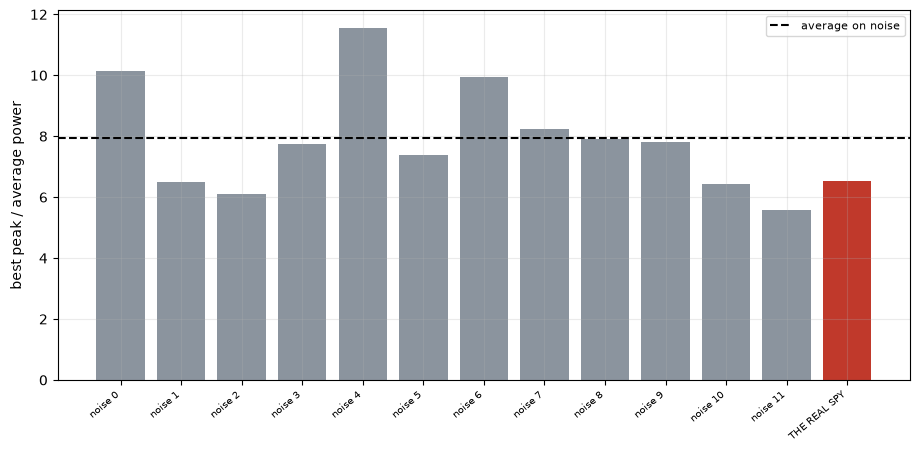

              period   power  fisher_p
source                                
noise 0       5.1590 10.1480    0.1400
noise 1       6.4810  6.4820    0.9600
noise 2       6.5030  6.0940    0.9920
noise 3      17.2530  7.7420    0.6030
noise 4       7.1760 11.5530    0.0360
noise 5       5.1080  7.3840    0.2220
noise 6       6.4170  9.9470    0.1680
noise 7      14.3780  8.2450    0.3670
noise 8       8.1900  7.9210    0.7570
noise 9       8.0120  7.8000    0.7980
noise 10     44.1140  6.4250    0.4780
noise 11     11.6400  5.5940    0.0760
THE REAL SPY  5.6420  6.5300    0.2330


In [11]:
rows = []
for k in range(12):
    sim_x = st.synthetic_series(n=len(lead), seed=1000 + k)
    p2 = st.periodogram(sim_x)
    f2 = st.fisher_g_test(p2)
    pk = st.top_peaks(p2, 1, 5.0, 750.0)
    rows.append({"source": f"noise {k}", "period": pk.iloc[0]["period"],
                 "power": pk.iloc[0]["relative_power"], "fisher_p": f2["p_value"]})
pk_real = st.top_peaks(pg, 1, 5.0, 750.0)
f_real = st.fisher_g_test(pg)
rows.append({"source": f"THE REAL {data.EQUITY}", "period": pk_real.iloc[0]["period"],
             "power": pk_real.iloc[0]["relative_power"], "fisher_p": f_real["p_value"]})
d = pd.DataFrame(rows).set_index("source")
fig, ax = plt.subplots(figsize=(11, 4.8))
colors = ["#8b949e"] * (len(d) - 1) + ["#c0392b"]
ax.bar(range(len(d)), d["power"], color=colors)
ax.axhline(d["power"].iloc[:-1].mean(), ls="--", color="k", lw=1.5,
           label="average on noise")
ax.set_xticks(range(len(d))); ax.set_xticklabels(d.index, rotation=40, ha="right",
                                                 fontsize=7)
ax.set_ylabel("best peak / average power"); ax.legend(fontsize=8)
plt.show()
print(d.round(3).to_string())

## 4 · The verdict

In [12]:
f_real = st.fisher_g_test(pg)
sim = st.spurious_peak_distribution(len(lead), n_sims=250, min_period=5.0)
sp = st.split_sample_peak(lead, 5.0, 750.0)
a1 = st.ar1_null(lead)
pa = st.peak_against_ar1(pg, a1["phi"])
tr = st.cycle_trade(lead, float(st.top_peaks(pg, 1, 5.0, 750.0).iloc[0]["period"]),
                    1000, 5.0)
pd.DataFrame({
    "frequency bins": [len(pg)],
    "best peak (sessions)": [f_real["peak_period"]],
    "its power vs average": [f_real["relative_power"]],
    "noise 95th percentile": [sim["p95_max"]],
    "Fisher p": [f_real["p_value"]],
    "AR(1) coefficient": [a1["phi"]],
    "peak after AR(1) correction": [pa["peak_period_ar1"]],
    "period ratio across halves": [sp["period_ratio"]],
    "phase error": [sp["phase_error_fraction"]],
    "out-of-sample Sharpe": [tr["sharpe"]],
}).T.rename(columns={0: "value"}).round(4)

,value
frequency bins,"3,882.0000"
best peak (sessions),4.0820
its power vs average,9.5869
noise 95th percentile,10.3057
Fisher p,0.2326
AR(1) coefficient,-0.0708
peak after AR(1) correction,4.0820
period ratio across halves,0.5720
phase error,0.4046
out-of-sample Sharpe,0.2225


## 5 · Going further

- **Multitaper estimation** (Thomson 1982) reduces the periodogram's variance properly instead
  of trading resolution for it the way a single taper does. It would sharpen every peak in
  section 1 and would not change the conclusion.
- **Wavelets.** A business cycle is not a sinusoid — it varies in length, which smears its power
  across bins and can hide it from a Fourier method entirely. A time-frequency decomposition is
  the right tool and would be a genuine follow-up rather than a refinement.
- **Print the null band, always.** The single highest-value change to how spectra are presented
  in finance is one extra line on the chart.
- **Look where there is a mechanism.** Natural gas has weather; retail has Christmas; equity
  indices have nothing that would generate a fixed multi-year sinusoid. A prior beats a
  *p*-value.